# NumPy: Linear Algebra

In [1]:
import sys; sys.path.append('..')
from dshub import np, linalg

## 1. Basic concepts
- Regular, lowercase letters are used for [scalars]. For example:

$$x=5,\;\alpha=0.2$$

- Bold, lowercase letters are [column vectors]. Adding a number in square brackets specifies the entry in the corresponding position. For example:

$$\mathbf{x}=\begin{bmatrix}2\\4\\5\end{bmatrix},\;\mathbf{x}[2]=4$$

- For row vectors, add a transpose operator to the column form. For example:

$$\mathbf{x}^{T}=\begin{bmatrix}2 & 4 & 5\end{bmatrix}$$

- Bold, uppercase letters are for [matrices]. Use $M\times N$ subscript for shape (rows x columns). Use $m,n$ to denote the entry in row $m$ and column $n$. For example:

$$\mathbf{A}_{3\times4}=\begin{bmatrix}1&2&3&4\\5&6&7&8\\9&10&11&12\end{bmatrix},\;\mathbf{A}_{2,3}=\mathbf{A}[2,3]=7$$

[scalars]: https://en.wikipedia.org/wiki/Scalar_(mathematics)
[column vectors]: https://en.wikipedia.org/wiki/Row_and_column_vectors
[matrices]: https://en.wikipedia.org/wiki/Matrix_(mathematics)

### 1.1. Special matrices

In [2]:
import sys; sys.path.append('..')
from dshub import np, linalg

#### Constant matrix
A constant matrix is a matrix in which all entries are the same. Popular constant matrices are [zero matrix] (denoted $\mathbf{0}$) and [matrix of ones] (denoted $\mathbf{J}$).

[zero matrix]: https://en.wikipedia.org/wiki/Zero_matrix
[matrix of ones]: https://en.wikipedia.org/wiki/Matrix_of_ones

In [3]:
np.zeros((3,4), dtype=int)

array([[0, 0, 0, 0],
       [0, 0, 0, 0],
       [0, 0, 0, 0]])

In [4]:
np.ones((4,6), dtype=int)

array([[1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1]])

#### Square matrix
A [square matrix] has the same number of rows and columns.

[square matrix]: https://en.wikipedia.org/wiki/Square_matrix

In [5]:
np.random.random((3,3))

array([[0.8447, 0.3092, 0.5861],
       [0.4203, 0.7364, 0.289 ],
       [0.2123, 0.2285, 0.3958]])

In [6]:
np.arange(9).reshape(3,3)

array([[0, 1, 2],
       [3, 4, 5],
       [6, 7, 8]])

#### Identity matrix
An [identity matrix] is a square matrix with ones on the main diagonal and zeros elsewhere, denoted $\mathbf{I}$ (dimension is populated based on calculations).

[identity matrix]: https://en.wikipedia.org/wiki/Identity_matrix

In [7]:
np.eye(N=5, dtype=int)

array([[1, 0, 0, 0, 0],
       [0, 1, 0, 0, 0],
       [0, 0, 1, 0, 0],
       [0, 0, 0, 1, 0],
       [0, 0, 0, 0, 1]])

#### Diagonal matrix
A [diagonal matrix] is a square matrix in which the elements outside the main diagonal are all zero. Given $\mathbf{a}=\begin{bmatrix}1 & 2 & 3\end{bmatrix}^{T}$, a diagonal matrix can be represented as below:

$$\begin{bmatrix}1&0&0 \\ 0&2&0 \\ 0&0&3 \end{bmatrix}=\text{diag}(\mathbf{a})=\text{diag}(1,2,3)$$

[diagonal matrix]: https://en.wikipedia.org/wiki/Diagonal_matrix

In [8]:
array = np.random.randint(10, size=(4,4))
np.diag(np.diag(array))

array([[2, 0, 0, 0],
       [0, 0, 0, 0],
       [0, 0, 4, 0],
       [0, 0, 0, 1]])

#### Triangular matrix
A [triangular matrix] is a special kind of square matrix, where all entries above or below the main diagonal are $0$. There are two types of triangular matrices: lower and upper.

[triangular matrix]: https://en.wikipedia.org/wiki/Triangular_matrix

In [9]:
array = np.random.randint(10, size=(4,4))
np.tril(array)

array([[7, 0, 0, 0],
       [8, 8, 0, 0],
       [2, 8, 5, 0],
       [3, 7, 0, 8]])

In [10]:
array = np.random.randint(10, size=(4,4))
np.triu(array)

array([[2, 5, 0, 9],
       [0, 6, 9, 5],
       [0, 0, 6, 9],
       [0, 0, 0, 4]])

### 1.2. Matrix operations

In [11]:
import sys; sys.path.append('..')
from dshub import np, linalg

#### Addition
Matrices must have the same shape for element-wise [addition] (or subtraction). The sum of $\mathbf{A}\in\mathbb{R}^{M\times N}$ and $\mathbf{B}\in\mathbb{R}^{M\times N}$ is calculated as:

$$(\mathbf{A}+\mathbf{B})_{m,n} = \mathbf{A}_{m,n} + \mathbf{B}_{m,n}$$

[addition]: https://en.wikipedia.org/wiki/Matrix_addition

In [12]:
A = np.array([
    [1, 2, 3],
    [4, 5, 6],
])

B = np.array([
    [7, 5, 8],
    [2, 0, 7]
])

In [13]:
A + B

array([[ 8,  7, 11],
       [ 6,  5, 13]])

In [14]:
B - A

array([[ 6,  3,  5],
       [-2, -5,  1]])

Alternatively, `np.add()` can be used.

In [15]:
np.add(A, B)

array([[ 8,  7, 11],
       [ 6,  5, 13]])

#### Scalar multiplication
For a scalar $c$ and a matrix $\mathbf{A}\in\mathbb{R}^{M\times N}$, the multiplication can be computed: $(c\mathbf{A})_{m,n} = c\cdot \mathbf{A}_{m,n}$

In [16]:
A = np.array([
    [1, 2, 3],
    [4, 5, 6]
])

In [17]:
A * 2

array([[ 2,  4,  6],
       [ 8, 10, 12]])

#### Element-wise product
The [Hadamard] (element-wise) product of two matrices $\mathbf{A}$ and $\mathbf{B}$ of the same size $M\times N$ is a matrix $\mathbf{C}\in\mathbb{R}^{M\times N}$.

$$\mathbf{C}_{m,n}=\mathbf{A}_{m,n}\odot\mathbf{B}_{m,n}$$

[Hadamard]: https://en.wikipedia.org/wiki/Hadamard_product_(matrices)

In [18]:
A = np.linspace(1, 12, 12, dtype=int).reshape(3,4)
A

array([[ 1,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12]])

In [19]:
B = np.linspace(6, 18, 12, dtype=int).reshape(3,4)
B

array([[ 6,  7,  8,  9],
       [10, 11, 12, 13],
       [14, 15, 16, 18]])

In [20]:
A * B

array([[  6,  14,  24,  36],
       [ 50,  66,  84, 104],
       [126, 150, 176, 216]])

#### Matrix multiplication
The [dot product] of $\mathbf{A}\in\mathbb{R}^{M\times N}$ and $\mathbf{B}\in\mathbb{R}^{N\times P}$ is a matrix $\mathbf{C}\in\mathbb{R}^{M\times P}$ where the elements of $\mathbf{C}$ are calculated by the formula:

$$\mathbf{C}_{m,p} = \sum_{n=1}^N {\mathbf{A}_{m,n}\mathbf{B}_{n,p}}$$

[dot product]: https://en.wikipedia.org/wiki/Matrix_multiplication

In [21]:
A = np.linspace(1, 6, 6, dtype=int).reshape(2, 3)
B = np.linspace(1, 12, 12, dtype=int).reshape(3, 4)

In [22]:
np.dot(A, B)

array([[ 38,  44,  50,  56],
       [ 83,  98, 113, 128]])

In [23]:
A @ B

array([[ 38,  44,  50,  56],
       [ 83,  98, 113, 128]])

#### Transposition
[Transposition] is an operator where the matrix is flipped over its diagonal. The transpose of the matrix $\mathbf{A}\in\mathbb{R}^{M\times N}$ is denoted $(\mathbf{A}^{T})\in\mathbb{R}^{N\times M}$ and satisfies:

$$(\mathbf{A}^{T})_{n,m}=\mathbf{A}_{m,n}$$

[Transposition]: https://en.wikipedia.org/wiki/Transpose

In [24]:
A = np.arange(24).reshape(3,8)
A

array([[ 0,  1,  2,  3,  4,  5,  6,  7],
       [ 8,  9, 10, 11, 12, 13, 14, 15],
       [16, 17, 18, 19, 20, 21, 22, 23]])

In [25]:
A.T

array([[ 0,  8, 16],
       [ 1,  9, 17],
       [ 2, 10, 18],
       [ 3, 11, 19],
       [ 4, 12, 20],
       [ 5, 13, 21],
       [ 6, 14, 22],
       [ 7, 15, 23]])

In [26]:
np.diag(A) == np.diag(A.T)

array([ True,  True,  True])

#### Properties
Here are some properties of matrix operations:
- $\mathbf{A}+\mathbf{B} = \mathbf{B}+\mathbf{A}$ (commutativity)
- $(c\mathbf{A})^{T} = c \cdot \mathbf{A}^{T}$
- $(\mathbf{A}+\mathbf{B})^{T} = \mathbf{A}^{T} + \mathbf{B}^{T}$
- $(\mathbf{A}^{T})^{T} = \mathbf{A}$
- $(\mathbf{A}\mathbf{B})\mathbf{C} = \mathbf{A}(\mathbf{B}\mathbf{C}) = \mathbf{A}\mathbf{B}\mathbf{C}$ (associativity)
- $(\mathbf{A}+\mathbf{B})\mathbf{C} = \mathbf{A}\mathbf{C} + \mathbf{B}\mathbf{C}$ (distributivity)
- $(\mathbf{AB})^T=\mathbf{B}^T\mathbf{A}^T $

### 1.3. Diagonal and trace

#### The diagonal
To get the [main diagonal] of a matrix, use the [`np.diag()`] function.

[main diagonal]: https://en.wikipedia.org/wiki/Main_diagonal
[`np.diag()`]: https://numpy.org/doc/stable/reference/generated/numpy.diag.html

In [27]:
import sys; sys.path.append('..')
from dshub import np, linalg

In [28]:
A = np.arange(12).reshape(3,4)
A

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [29]:
np.diag(A)

array([ 0,  5, 10])

In [30]:
np.diag(A, k=1)

array([ 1,  6, 11])

#### The trace
The [trace] of a square matrix is the sum of the main diagonal elements. Despite that Numpy supports calculating the trace for any type of matrix, Mathematics defines the trace for square matrices only.

[trace]: https://en.wikipedia.org/wiki/Trace_(linear_algebra)

In [31]:
A = np.arange(12).reshape(3,4)
A

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [32]:
A.trace()

np.int64(15)

In [33]:
np.diag(A).sum()

np.int64(15)

### 1.4. Echelon form and rank

In [34]:
import sys; sys.path.append('..')
from dshub import np, linalg

#### Gaussian elimination
[Gaussian elimination] (also known as row reduction) is a linear algebra algorithm for solving a system of linear equations; finding the rank, the determinant and the inverse of matrices. There are three types of elementary matrix operations:
- Interchanging two rows
- Multiplying a row by a non-zero number
- Adding a multiple of a row to another row

[Gaussian elimination]: https://en.wikipedia.org/wiki/Gaussian_elimination

#### Echelon form
Using Gaussian elimination, any matrix can be transformed to the [row echelon form] or column echelon form. From now on, echelon form refers to row echelon.

$$
\begin{bmatrix}
    a & * & * & * & * & * & * & * & * \\
    0 & 0 & b & * & * & * & * & * & * \\
    0 & 0 & 0 & c & * & * & * & * & * \\
    0 & 0 & 0 & 0 & 0 & 0 & d & * & * \\
    0 & 0 & 0 & 0 & 0 & 0 & 0 & e & * \\
    0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
\end{bmatrix}
$$

A matrix is in echelon form when it satisfies the following conditions:
- All zero rows (rows with all zero elements) are at the bottom.
- Each [pivot] (or leading entry) - the leftmost non-zero element of each row is always to the right of the above pivot. In the example above, $a$, $b$, $c$, $d$ and $e$ are pivots.

[row echelon form]: https://en.wikipedia.org/wiki/Row_echelon_form
[pivot]: https://en.wikipedia.org/wiki/Pivot_element

In [35]:
A = np.array(
    [[0, 1, 2],
     [1, 2, 1],
     [2, 7, 8]]
)
_, _, echelon = linalg.lu(A)
echelon

array([[ 2. ,  7. ,  8. ],
       [ 0. , -1.5, -3. ],
       [ 0. ,  0. ,  0. ]])

#### Rank-nullity theorem
The [rank] of a matrix is the maximum number of *linearly independent* rows in the matrix. A vector is linearly dependent if it can be written as a linear combination of other vectors. The rank of $\mathbf{A}\in\mathbb{R}^{M\times N}$ is at most $\min(M,N)$. If it attains that bound, we say $\mathbf{A}$ is full-rank; otherwise, it's rank-deficient. This can be expressed using the
[rank-nullity theorem]:

$$\text{rank}(A)+\text{nullity}(A)=\min(M,N)$$

[rank]: https://en.wikipedia.org/wiki/Rank_(linear_algebra)
[rank-nullity theorem]: https://en.wikipedia.org/wiki/Rank%E2%80%93nullity_theorem

In [36]:
np.linalg.matrix_rank(A)

np.int64(2)

### 1.5. Determinant and inverse
These attributes are defined only for square matrices.

In [1]:
import sys; sys.path.append('..')
from dshub import np, linalg

#### Minors and cofactors
[Minors] and cofactors are used to compute determinants and inverses of square matrices.  
Given a square matrix $\mathbf{A}\in\mathbb{R}^{N\times N}$ and $i,j\in\{1,2,\dots,N\}$:

- The $(i,j)$ minor is $m_{ij}=\det(A_{(i,j)})$, where $A_{(i,j)}$ is the $(N-1)\times(N-1)$ [submatrix] obtained by deleting the $i$-th row and $j$-th column.
- The corresponding cofactor is $\mathbf{C}_{i,j}=(-1)^{i+j}\,m_{ij}$.

Collecting all cofactors gives the cofactor matrix $\mathbf{C}=[\mathbf{C}_{i,j}]$. The [adjugate matrix] is the transpose of the cofactor matrix.

[Minors]: https://en.wikipedia.org/wiki/Minor_(linear_algebra)
[submatrix]: https://proofwiki.org/wiki/Definition:Submatrix
[adjugate matrix]: https://en.wikipedia.org/wiki/Adjugate_matrix


#### Determinant
The [determinant] of a $2\times 2$ matrix is:
$$
\begin{vmatrix}
a_{1,1} & a_{1,2}\\
a_{2,1} & a_{2,2}
\end{vmatrix}
= a_{1,1}a_{2,2} - a_{1,2}a_{2,1}.
$$

To compute the determinant of a square matrix $\mathbf{A}\in\mathbb{R}^{N\times N}$ (written $\det(\mathbf{A})$ or $|\mathbf{A}|$), you can use the [Laplace expansion] (a recursive formula based on minors and cofactors). Expanding along column $j$ (with $j$ fixed, $j\in\{1,\dots,N\}$):

$$
\det(\mathbf{A}) = \sum_{i=1}^N a_{ij}(-1)^{i+j}m_{ij}
= \sum_{i=1}^N a_{ij}C_{ij}.
$$


[determinant]: https://en.wikipedia.org/wiki/Determinant
[Laplace expansion]: https://en.wikipedia.org/wiki/Laplace_expansion

In [2]:
np.random.seed(0)
A = np.random.randint(1, 10, (5,5))
A

array([[6, 1, 4, 4, 8],
       [4, 6, 3, 5, 8],
       [7, 9, 9, 2, 7],
       [8, 8, 9, 2, 6],
       [9, 5, 4, 1, 4]])

In [39]:
linalg.det(A)

np.float64(-1552.9999999999998)

#### Inverse
The [inverse] of the square matrix $\mathbf{A}\in\mathbb{R}^{N\times N}$ is denoted $\mathbf{A}^{-1}$ and satisfies $\mathbf{A}\mathbf{A}^{-1} = \mathbf{I}$. $\mathbf{A}$ is invertible only if $|\mathbf{A}| \ne 0$. With $\mathbf{C}$ denotes the adjugate matrix, the formula for inversion is:

$$\mathbf{A}^{-1} = \frac{1}{|\mathbf{A}|}\mathbf{C}^{T}$$

Inferred from the above formula, a square matrix having determinant of $0$ has no inverse. Such a matrix is called a *singular matrix*. Otherwise, the matrix is said to be *invertible*.

[inverse]: https://en.wikipedia.org/wiki/Invertible_matrix

In [3]:
A = np.array([
    [1, 2, 3],
    [0, 1, 4],
    [5, 6, 0]]
)
linalg.inv(A)

array([[-24.,  18.,   5.],
       [ 20., -15.,  -4.],
       [ -5.,   4.,   1.]])

Let's check if the dot product of $\mathbf{A}$ and $\mathbf{A}^{-1}$ is an identity matrix.

In [4]:
np.allclose(
    A @ linalg.inv(A),
    np.eye(A.shape[0])
)

True

### 1.6. Eigenvalues

#### Calculation
[Eigenvalues and eigenvectors] are defined only for square matrices. Each eigenvalue $(\lambda)$ and a corresponding eigenvector $(\mathbf{x})$ of the square matrix $\mathbf{A}$ satisfies: $\mathbf{A}\mathbf{x} = \lambda \mathbf{x}$. To find eigenvalues and eigenvectors:
- Solve the equation: $|\mathbf{A} - \lambda \mathbf{I}| = 0$ (called the [characteristic equation]) for $\lambda$.
- For each value of $\lambda$ found, solve the equation $(\mathbf{A}-\lambda\mathbf{I})\;\mathbf{x}=0$ or use Gaussian elimination to convert the [augmented matrix] $(\mathbf{A} - \lambda \mathbf{I}\mid0)$ to echelon form then solve it as a system of linear equations.  

Note that there are infinitely many eigenvectors corresponding to a single eigenvalue; they are linearly dependent (scalar multiples of each other).

[Eigenvalues and eigenvectors]: https://en.wikipedia.org/wiki/Eigenvalues_and_eigenvectors
[characteristic equation]: https://en.wikipedia.org/wiki/Characteristic_polynomial
[augmented matrix]: https://en.wikipedia.org/wiki/Augmented_matrix

In [0]:
import sys; sys.path.append('..')
from dshub import np, linalg

In [5]:
A = np.array([
    [3, 4, -2],
    [1, 4, -1],
    [2, 6, -1]]
)
eigenvalues, eigenvectors = linalg.eig(A)

In [6]:
eigenvalues

array([3.+0.j, 2.+0.j, 1.+0.j])

In [7]:
eigenvalues.sum()

np.complex128(5.9999999999999964+0j)

In [8]:
eigenvectors
# each column is an eigenvector

array([[-0.4082,  0.    ,  0.7071],
       [-0.4082,  0.4472, -0.    ],
       [-0.8165,  0.8944,  0.7071]])

In [9]:
eigenvectors[:, 0]

array([-0.4082, -0.4082, -0.8165])

Now calculate the value of $\mathbf{A}\mathbf{x}$ and $\lambda \mathbf{x}$ and check if they are equal.

In [10]:
lhs = A @ eigenvectors[:,0]
rhs = eigenvalues[0] * eigenvectors[:,0]
np.allclose(lhs, rhs)

True

#### Properties
- The sum of all eigenvalues is the same as the trace of $\mathbf{A}$.
- The product of all eigenvalues is the same as the determinant of $\mathbf{A}$.
- $\mathbf{A}$ and $\mathbf{A}^T$ have the same set of eigenvalues.

## 2. Decomposition

### 2.1. Eigendecomposition
[Eigendecomposition] expresses a square matrix $\mathbf{A}\in\mathbb{R}^{N\times N}$ in terms of its eigenvalues and eigenvectors. It works only if $\mathbf{A}$ is diagonalizable (i.e. non-defective). $\mathbf{A}$ can be written as:

$$\mathbf{A}=\mathbf{Q}\mathbf{D}\mathbf{Q}^{-1}$$

Where $\mathbf{Q}$ is the matrix of eigenvectors, $\mathbf{D}$ stores eigenvalues on its diagonal.

[Eigendecomposition]: https://en.wikipedia.org/wiki/Eigendecomposition_of_a_matrix
[non-defective matrices]: https://en.wikipedia.org/wiki/Diagonalizable_matrix

In [11]:
import sys; sys.path.append('..')
from dshub import np, linalg

In [12]:
A = np.array([
    [3, 4, -2],
    [1, 4, -1],
    [2, 6, -1]
], dtype=float)
eigenvalues, eigenvectors = linalg.eig(A)
D = np.diag(eigenvalues)
Q = eigenvectors

In [13]:
lhs = A
rhs = Q @ D @ linalg.inv(Q)
np.allclose(lhs, rhs)

True

#### Properties
- We can easily prove that: $\mathbf{A}^k=\mathbf{Q}\mathbf{D}^k\mathbf{Q}^{-1}$. By letting $k=-1$, this property can be used to compute the inverse of $\mathbf{A}$.
- When $\mathbf{A}$ is a [symmetric matrix] ($\mathbf{A}=\mathbf{A}^{T}$), it is always diagonalizable and its eigenvectors are [orthonormal]. Thus, $\mathbf{Q}$ becomes an [orthogonal matrix]. This wonderful property is the foundation of famous PCA (Principal Components Analysis).

[symmetric matrix]: https://en.wikipedia.org/wiki/Symmetric_matrix
[orthonormal]: https://en.wikipedia.org/wiki/Orthonormality
[orthogonal matrix]: https://en.wikipedia.org/wiki/Orthogonal_matrix

In [14]:
power = 5

lhs = np.linalg.matrix_power(A, power)
rhs = Q @ np.linalg.matrix_power(D, power) @ linalg.inv(Q)

np.allclose(lhs, rhs)

True

#### Diagonalization
Diagonalization is the process of transforming a square matrix to a diagonal matrix so that it retains the main properties. By performing eigendecomposition, we are diagonalizing $\mathbf{A}$ into $\mathbf{D}$. Let's analyze the situation to understand how $\mathbf{D}$ shares the same characteristics with $\mathbf{A}$.

$$
\begin{aligned}
    \mathbf{Ax} &= \mathbf{y} \\
    \Leftrightarrow\mathbf{Q}\mathbf{D}\mathbf{Q}^{-1}\mathbf{x} &= \mathbf{y} \\
    \Leftrightarrow\mathbf{D}\left(\mathbf{Q}^{-1}\mathbf{x}\right) &= \left(\mathbf{Q}^{-1}\mathbf{y}\right)
\end{aligned}
$$

In the first equation, $\mathbf{y}$ is the image of $\mathbf{x}$ in the new coordinates system proposed by $\mathbf{A}$. In the third equation, notice that both $\mathbf{x}$ and $\mathbf{y}$ are transformed in the same way. We can conclude that $\mathbf{D}$ represents the simplest form of $\mathbf{A}$ that requires less entries ($N$ instead of $N^2$).

### 2.2. SVD
[Singular Value Decomposition] (SVD) is the generalization of eigendecomposition of a square matrix to any rectangular matrix. In Machine Learning, it has a lot of applications such as finding [pseudo-inverse] and solving for [least squares] problems. SVD says that any matrix $\mathbf{A}\in\mathbb{R}^{M\times N}$ can be factorized into:

$$\mathbf{A}=\mathbf{U}\mathbf{S}\mathbf{V}^{T}$$

where:
- $\mathbf{U}\in\mathbb{R}^{M\times M}$ stores the eigenvectors of $\mathbf{A}\mathbf{A}^{T}$
- $\mathbf{V}\in\mathbb{R}^{N\times N}$ stores the eigenvectors of $\mathbf{A}^{T}\mathbf{A}$
- $\mathbf{S}\in\mathbb{R}^{M\times N}$ is a diagonal matrix with singular values lying on the diagonal

[Singular Value Decomposition]: https://en.wikipedia.org/wiki/Singular_value_decomposition
[pseudo-inverse]: https://en.wikipedia.org/wiki/Moore%E2%80%93Penrose_inverse
[least squares]: https://en.wikipedia.org/wiki/Total_least_squares

In [15]:
import sys; sys.path.append('..')
from dshub import np, linalg

In [16]:
A = np.array([
    [4, 9, 4, 6],
    [5, 7, 4, 5],
    [3, 1, 7, 9],
])

U, S, Vh = linalg.svd(A)

In [17]:
U

array([[ 0.6253,  0.453 ,  0.6354],
       [ 0.5556,  0.3133, -0.7702],
       [ 0.548 , -0.8346,  0.0558]])

In [18]:
S

array([18.8115,  6.9597,  1.2991])

In [19]:
Vh

array([[ 0.368 ,  0.5351,  0.455 ,  0.6093],
       [ 0.1257,  0.781 , -0.3991, -0.4637],
       [-0.8789,  0.295 , -0.1142,  0.3571],
       [ 0.2763, -0.1293, -0.7878,  0.535 ]])

#### Properties
Because $\mathbf{A}\mathbf{A}^{T}$ and $\mathbf{A}^{T}\mathbf{A}$ are symmetric, their eigenvectors are orthogonal. Consequently, $\mathbf{U}$ and $\mathbf{V}$ are orthogonal matrices. An orthogonal matrix is unitary:

$$\mathbf{U}\mathbf{U}^{T}=\mathbf{U}\mathbf{U}^{-1}=\mathbf{I}$$

$\mathbf{A}\mathbf{A}^{T}$ and $\mathbf{A}^{T}\mathbf{A}$ in fact share the same set of positive eigenvalues. It turns out, their square roots are the singular values which lie on the diagonal of $\mathbf{S}$. This relationship can be expressed using the eigendecomposition of either $\mathbf{A}\mathbf{A}^{T}$ or $\mathbf{A}^{T}\mathbf{A}$:

$$\begin{aligned}
\mathbf{A}\mathbf{A}^{T}
&= \left(\mathbf{U}\mathbf{S}\mathbf{V}^{T}\right)\left(\mathbf{U}\mathbf{S}\mathbf{V}^{T}\right)^{T} \\
&= \mathbf{U}\mathbf{S}\mathbf{V}^{T}\mathbf{V}\mathbf{S}^{T}\mathbf{U}^{T} \\
&= \mathbf{U}(\mathbf{S}\mathbf{S}^{T})\mathbf{U}^{-1} \\
\end{aligned}$$

As $\mathbf{S}$ is a diagonal matrix, to calculate $\mathbf{S}\mathbf{S}^{T}$ we only need to square the elements on the diagonal of $\mathbf{S}$. In other words, squaring singular values of $\mathbf{A}$ gives us the eigenvalues of $\mathbf{A}\mathbf{A}^{T}$.

### 2.3. QR decomposition
[QR decomposition] factors a matrix $\mathbf{A}$ into $\mathbf{QR}$, where $\mathbf{Q}$ is triangular and $\mathbf{R}$ is upper triangular. One method to compute it is via the [Gram-Schmidt process].

[QR decomposition]: https://en.wikipedia.org/wiki/QR_decomposition
[Gram-Schmidt process]: https://en.wikipedia.org/wiki/Gram%E2%80%93Schmidt_process

In [20]:
import sys; sys.path.append('..')
from dshub import np, linalg

In [21]:
A = np.array([
    [4, 9, 4],
    [5, 7, 4],
    [3, 1, 7]
])

Q, R = linalg.qr(A)

In [22]:
Q

array([[-0.5657,  0.6646,  0.4882],
       [-0.7071, -0.0863, -0.7018],
       [-0.4243, -0.7422,  0.5187]])

In [23]:
R

array([[ -7.0711, -10.4652,  -8.061 ],
       [  0.    ,   4.6347,  -2.8826],
       [  0.    ,   0.    ,   2.7768]])

## 3. Geometric meaning

In [27]:
import sys; sys.path.append('..')
from dshub import np, linalg, plt

In [45]:
def plot_vectors(data, ax=None, figsize=(4,6)):
    data = np.array(data).T
    num_vectors = data.shape[1]

    initial = np.zeros((2, num_vectors), dtype=float)
    data = np.concatenate([initial, data], axis=0)

    default = np.array([0, 1e-6, 0, 0, 'black']).reshape(-1, 1)
    data = np.concatenate([default, data], axis=1)

    c = data[4]
    data = data[:4].astype(float)
    x, y, u, v = data

    edge = 0.5
    
    right = np.max(x + u)
    if right < 0: right = 0
    right += edge
    
    left = np.min(x + u)
    if left > 0: left = 0
    left -= edge
    
    upper = np.max(y + v)
    if upper < 0: upper = 0
    upper += edge
    
    lower = np.min(y + v)
    if lower > 0: lower = 0
    lower -= edge

    fig, ax = plt.subplots(figsize=figsize) if ax is None else (ax.figure, ax)

    ax.xaxis.set_major_locator(plt.MultipleLocator(1))
    ax.yaxis.set_major_locator(plt.MultipleLocator(1))
    ax.quiver(x, y, u, v,
        color=c,
        units='xy',
        scale=1
    )
    ax.axis('scaled')
    ax.set_xlim(left, right)
    ax.set_ylim(lower, upper)

### 3.1. Scalars
Multiplying a vector $\mathbf{a}$ by a scalar $c$ has the following effects:
- If $|c|>1$ then $\mathbf{a}$ stretches, if $|c|<1$ then $\mathbf{a}$ shrinks.
- The sign of $c$ tells us the direction of the new vector: positive means same direction, negative means opposite direction.

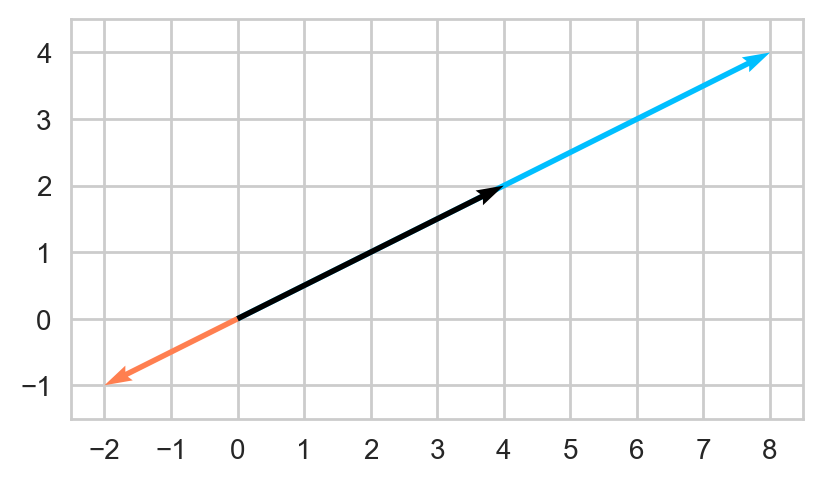

In [46]:
data = [
    [8, 4, 'deepskyblue'],
    [-2, -1, 'coral'],
    [4, 2, 'black'],
]

plot_vectors(data, figsize=(4,6))

### 3.2. Column vectors
In a 2-dimensional $xy$-coordinates, we conventionally call $\mathbf{i}_1$ and $\mathbf{i}_2$ the [basis/unit vectors]:

$$\mathbf{i}_1=\begin{bmatrix}1\\0\end{bmatrix},\;\mathbf{i}_2=\begin{bmatrix}0\\1\end{bmatrix}$$

Any vector $\mathbf{a}$ can always be represented by these basis vectors, for example:

$$\mathbf{a}=\begin{bmatrix}3\\2\end{bmatrix}=3\mathbf{i}_1+2\mathbf{i}_2$$

Note that there are an infinite number of representations of $\mathbf{a}$. By convention, all vectors originate at the origin, so only their *terminal point* matters.

[basis/unit vectors]: https://en.wikipedia.org/wiki/Basis_(linear_algebra)

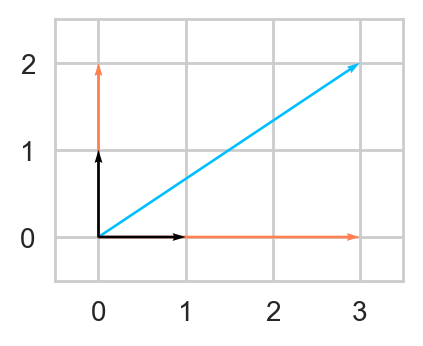

In [47]:
data = [
    [3, 2, 'deepskyblue'],
    [3, 0, 'coral'],
    [0, 2, 'coral'],
    [1, 0, 'black'],
    [0, 1, 'black'],
]

plot_vectors(data, figsize=(2,3))

### 3.3. Square matrices
A square matrix represents a *change* of basis vectors. For example, let's consider the matrix:

$$\mathbf{A}=\begin{bmatrix}2&1\\0&3\end{bmatrix}$$

$\mathbf{A}$ represents a new coordinates system, in which $(\mathbf{a}_1,\mathbf{a}_2)$ become the new basis:

$$\mathbf{a}_1=\begin{bmatrix}2\\0\end{bmatrix},\;\mathbf{a}_2=\begin{bmatrix}1\\3\end{bmatrix}$$

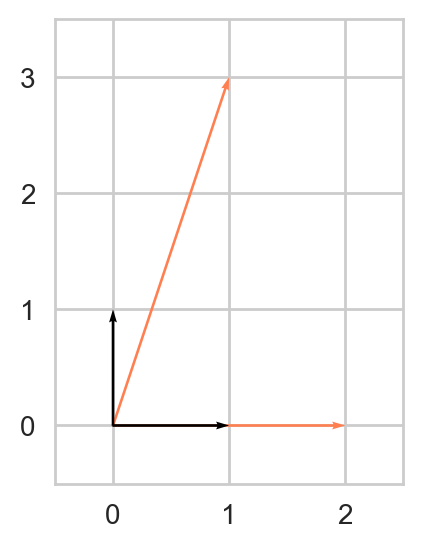

In [49]:
data = [
    [2, 0, 'coral'],
    [1, 3, 'coral'],
    [1, 0, 'black'],
    [0, 1, 'black'],
]

plot_vectors(data, figsize=(2,3))

### 3.4. Dot product
In this part, we are discover the geometric meaning of the dot a product between a square matrix $\mathbf{A}_{N\times N}$ with a column vector $\mathbf{b}_{N\times 1}$. As far as we know, a square matrix can be thought as a *container* of new basis, where each column represents a basis vector: $\mathbf{A}=[\mathbf{a}_1,\mathbf{a}_2,\dots,\mathbf{a}_N]$. For a specific case of $N=2$, the dot product $\mathbf{Ab}$ is derived as follow:

$$
\mathbf{A}\mathbf{b} =
\begin{bmatrix}\begin{array}{r} 2&-1 \\ 0&1 \end{array}\end{bmatrix}
\begin{bmatrix}\begin{array}{r} 3 \\ 4 \end{array}\end{bmatrix}
=
3\begin{bmatrix}\begin{array}{r} 2 \\ 0 \end{array}\end{bmatrix} +
4\begin{bmatrix}\begin{array}{r} -1 \\ 1 \end{array}\end{bmatrix}
=
3\mathbf{a}_1+4\mathbf{a}_2
$$

By treating $\mathbf{A}$ as a set of new basis vectors, $(\mathbf{a}_1,\mathbf{a}_2)$, we can now construct a brand new coordinates system. The geometric meaning of the product $\mathbf{Ab}$ is where $\mathbf{b}$ points to in the new coordinates. A special case of dot product is when $\mathbf{A}$ is a unit matrix, then we have $\mathbf{b}=\mathbf{A}\mathbf{b}$. This equation tells us a unit matrix is just the same old representation of the original basis.

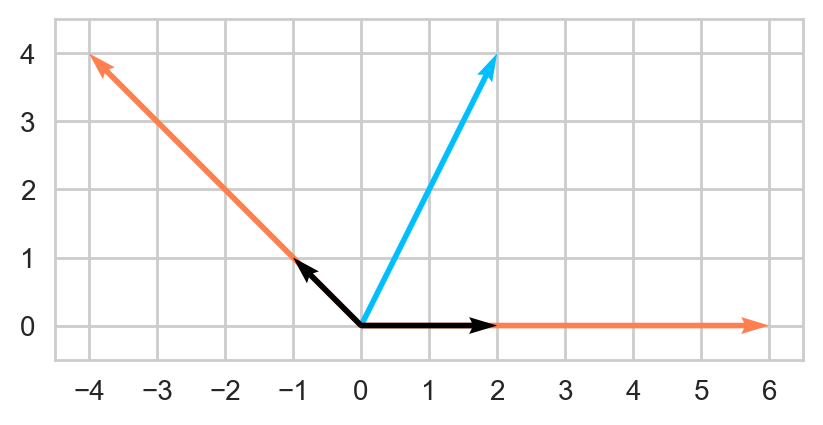

In [50]:
data = [
    [2, 4, 'deepskyblue'],
    [6, 0, 'coral'],
    [-4, 4, 'coral'],
    [2, 0, 'black'],
    [-1, 1, 'black'],
]

plot_vectors(data)

### 3.5. Determinant
The determinant of a matrix
$\mathbf{M}_{2\times 2}=\begin{bmatrix}\begin{array}{r} a&c \\ b&d \end{array}\end{bmatrix}$
is the area of the [parallelogram] formed by new basis vectors.

:::{image} ../image/chap_02/parallelogram.png
:height: 270px
:align: center
:::

For the matrix
$\mathbf{R}_{3\times 3}=\left[\begin{array}{c|c|c|c}\mathbf{r}_1 & \mathbf{r}_2 & \mathbf{r}_3\end{array}\right]$,
its determinant is the volume of the [parallelepiped] formed by 3 new basis vectors.

:::{image} ../image/chap_02/parallelepiped.png
:height: 270px
:align: center
:::

[parallelogram]: https://en.wikipedia.org/wiki/Parallelogram
[parallelepiped]: https://en.wikipedia.org/wiki/Parallelepiped

:::{note}
A square matrix has the determinant of $0$ only when there is at least one of its vectors is *linear dependent* on the others. Assume the matrix $\mathbf{R}_{3\times 3}$ above has the determinant of $0$, then it can be one of the following situations:
- There are at least one vector is $\mathbf{0}$
- There are at least a pair of vectors is parallel
- All three vectors lie in the same plane

Basically, if $\det\left(\mathbf{R}\right)=0$ then the new coordinates system has less than 3 dimensions.
:::

### 3.6. Inverse
If a matrix $\mathbf{A}_{N\times N}$ changes the basis, then $\mathbf{A}^{-1}$ is the inverse transform that changes back to the old coordinates. The reason behind this is the equation $\mathbf{A}\cdot\mathbf{A}^{-1} = \mathbf{I}_N$.

If $\det\left(\mathbf{A}\right)=0$ then $\mathbf{A}$ maps the original coordinates into a new, lower dimensional space. In this case, the inverse transform cannot be performed; in other words, $\mathbf{A}$ is  *non-invertible*.

## Resources
- gregorygundersen.com - [A Geometrical Understanding of Matrices](https://gregorygundersen.com/blog/2018/10/24/matrices/)